In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from matplotlib import pyplot as plt

%matplotlib widget

In [4]:
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/ADS/Grading/2024_ADS/ADS_Exam_2024_Retake_results.csv")

In [6]:
exam_results = pd.read_csv(exam_result_path, sep=";")
exam_results

,Name,Login,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,...,STAT_p-value,STAT_parametric_vs_non-parametric_b,STAT_power,STAT_unifactorial_anova,VIS_boxplots_b,VIS_histograms_2_b,VIS_scatter_plots_2,VIS_scatter_plots_b,VIS_STAT_outliers,VIS_STAT_outliers2_b
0,"Baghnavi, Sarina",vi92tyju,1,1,68.5,100,passed,49,49,1.000000,...,1,2,1,2,0.5,2,0,1,2,2
1,"Daum, Amelie",ku05zuji,1,1,84.0,100,passed,49,49,1.000000,...,2,2,2,2,2.0,2,0,1,1,2
2,"Dilli Ravi, Harikrishnan Hari Krishnan",if76evax,1,1,75.5,100,passed,48,49,0.979592,...,2,2,2,2,1.5,2,0,2,2,2
3,"Hedayati Sepehri, Amirali",qe12zivy,1,1,78.0,100,passed,49,49,1.000000,...,2,2,1,1,1.5,2,1,1,2,2
4,"Homayounfar, Mohammadsaeid",py97nyfi,1,1,88.0,100,passed,49,49,1.000000,...,2,2,2,1,2.0,2,2,2,2,2
5,"Obahji, Mohamad",ag46abiw,1,1,75.0,100,passed,48,49,0.979592,...,2,2,2,2,1.0,2,2,0,2,2
6,"Sedran, Lucas",ug96azyf,1,1,88.5,100,passed,49,49,1.000000,...,2,2,2,2,1.5,1,2,2,2,2


In [29]:
#handle special cases

exam_results.replace("exam76964", "ej80ogyg", inplace=True)

In [7]:
exam_results.set_index("Login", inplace=True)
exam_results.index.names = ["student_id"]
exam_results.head()

,Name,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,...,STAT_p-value,STAT_parametric_vs_non-parametric_b,STAT_power,STAT_unifactorial_anova,VIS_boxplots_b,VIS_histograms_2_b,VIS_scatter_plots_2,VIS_scatter_plots_b,VIS_STAT_outliers,VIS_STAT_outliers2_b
student_id,,,,,,,,,,,,,,,,,,,,,
vi92tyju,"Baghnavi, Sarina",1,1,68.5,100,passed,49,49,1.000000,00:38:20,...,1,2,1,2,0.5,2,0,1,2,2
ku05zuji,"Daum, Amelie",1,1,84.0,100,passed,49,49,1.000000,00:58:14,...,2,2,2,2,2.0,2,0,1,1,2
if76evax,"Dilli Ravi, Harikrishnan Hari Krishnan",1,1,75.5,100,passed,48,49,0.979592,00:35:36,...,2,2,2,2,1.5,2,0,2,2,2
qe12zivy,"Hedayati Sepehri, Amirali",1,1,78.0,100,passed,49,49,1.000000,00:57:44,...,2,2,1,1,1.5,2,1,1,2,2
py97nyfi,"Homayounfar, Mohammadsaeid",1,1,88.0,100,passed,49,49,1.000000,00:54:29,...,2,2,2,1,2.0,2,2,2,2,2


<Axes: >

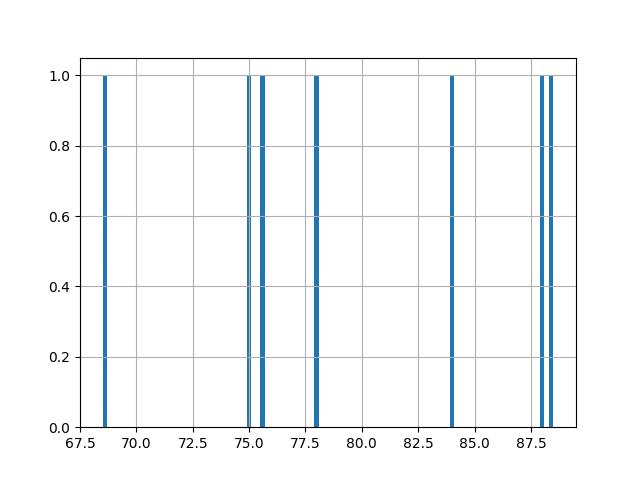

In [8]:
plt.subplots()
points = exam_results["Test Results in Points"]
points.hist(bins=100)

In [9]:
points = pd.DataFrame(points)
points.columns = ["points"]
points.head()

,points
student_id,
vi92tyju,68.5
ku05zuji,84.0
if76evax,75.5
qe12zivy,78.0
py97nyfi,88.0


In [10]:
pass_score = 48.0
max_score = 100.0
bin_size = round((max_score-pass_score) / 11, 1)
bin_size

4.7

In [11]:
grades = [1.0, 1.33, 1.66, 2.0, 2.33, 2.66, 3.0, 3.33, 3.66, 4.0, 4.33, 5.0]
grades = grades[::-1]

In [12]:
min_points = [pass_score + bin_size * i for i in range(-2,len(grades)-1)]
min_points

[38.6,
 43.3,
 48.0,
 52.7,
 57.4,
 62.1,
 66.8,
 71.5,
 76.2,
 80.9,
 85.6,
 90.30000000000001,
 95.0]

In [13]:
grade_map = pd.DataFrame(zip(min_points, grades), columns=["min_points", "grade"])
grade_map["max_points"] = grade_map["min_points"] + bin_size - 0.1
grade_map.set_index("grade", inplace=True)
grade_map.loc[1.0, "max_points"] = max_score
grade_map.loc[5.0, "min_points"] = 0.0

grade_map.sort_index(inplace=True)

grade_map

,min_points,max_points
grade,,
1.00,90.3,100.0
1.33,85.6,90.2
1.66,80.9,85.5
2.00,76.2,80.8
2.33,71.5,76.1
2.66,66.8,71.4
3.00,62.1,66.7
3.33,57.4,62.0
3.66,52.7,57.3


In [14]:
# return the value of the index of grade_map where points is between min_points and max_points
points["grade"] = [grade_map[(grade_map["min_points"] <= point) & (grade_map["max_points"] >= point)].index[0] for point in points["points"]]
points


,points,grade
student_id,,
vi92tyju,68.5,2.66
ku05zuji,84.0,1.66
if76evax,75.5,2.33
qe12zivy,78.0,2.00
py97nyfi,88.0,1.33
ag46abiw,75.0,2.33
ug96azyf,88.5,1.33


<Axes: >

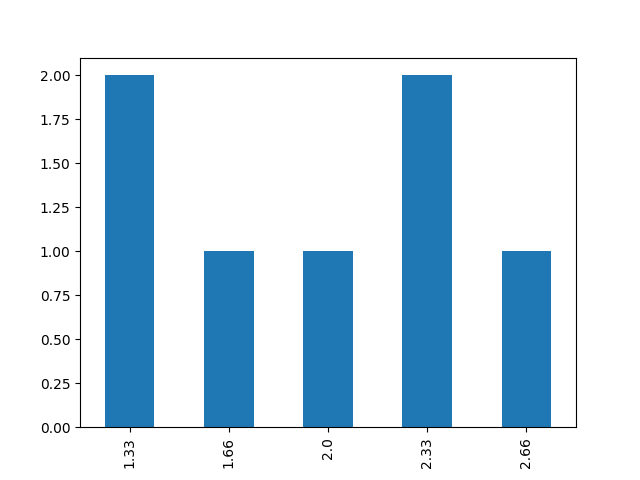

In [15]:
# Without Bonus

plt.subplots()

points["grade"].value_counts().sort_index().plot(kind="bar")

In [16]:
bonus_points = pd.read_csv("/Users/abelluc/Code/ads_exercise/total_score/2024_final.csv")
bonus_points.set_index("identifier", inplace=True)
bonus_points.index.names = ["student_id"]
bonus_points

,score_percent
student_id,
ac13atok,9.0
ac28azeg,1.0
ag46abiw,0.0
as73isud,100.0
at74ynyg,2.5
cu40xetu,95.5
cy73sela,41.0
ec40odyf,35.0
ej80ogyg,0.0


In [19]:
# join points and bonus_points

points = points.join(bonus_points)
# points.drop("student_id", axis=1, inplace=True)
points

,points,grade,bonus,score_percent
student_id,,,,
vi92tyju,68.5,2.66,0.0,NaN
ku05zuji,84.0,1.66,0.0,NaN
if76evax,75.5,2.33,0.0,NaN
qe12zivy,78.0,2.00,0.0,NaN
py97nyfi,88.0,1.33,0.0,NaN
ag46abiw,75.0,2.33,0.0,0.0
ug96azyf,88.5,1.33,0.0,NaN


In [20]:
# replace values in score_percent with 0.33, 0.66, 1.0
points["bonus"] = np.zeros(len(points))

points["bonus"][points["score_percent"] >= 95] = 0.66
points["score_percent"][points["score_percent"] >= 95] = 0

points["bonus"][points["score_percent"] >= 90] = 0.33

# replace nan with 0
points.fillna(0, inplace=True)

points.drop("score_percent", axis=1, inplace=True)
points

,points,grade,bonus
student_id,,,
vi92tyju,68.5,2.66,0.0
ku05zuji,84.0,1.66,0.0
if76evax,75.5,2.33,0.0
qe12zivy,78.0,2.00,0.0
py97nyfi,88.0,1.33,0.0
ag46abiw,75.0,2.33,0.0
ug96azyf,88.5,1.33,0.0


In [21]:
points["grade_with_bonus"] = points["grade"] - points["bonus"]

# set grade_with_bonus to 1.0 if grade_with_bonus is smaller than 1.0
points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0

# set grade_with_bonus to grade value if grade is greater than 4.0
points["grade_with_bonus"][points["grade"] > 4.0] = points["grade"]

points

,points,grade,bonus,grade_with_bonus
student_id,,,,
vi92tyju,68.5,2.66,0.0,2.66
ku05zuji,84.0,1.66,0.0,1.66
if76evax,75.5,2.33,0.0,2.33
qe12zivy,78.0,2.00,0.0,2.00
py97nyfi,88.0,1.33,0.0,1.33
ag46abiw,75.0,2.33,0.0,2.33
ug96azyf,88.5,1.33,0.0,1.33


In [22]:
points = round(points, 1)
points.sort_values("grade", inplace=True)
points

,points,grade,bonus,grade_with_bonus
student_id,,,,
py97nyfi,88.0,1.3,0.0,1.3
ug96azyf,88.5,1.3,0.0,1.3
ku05zuji,84.0,1.7,0.0,1.7
qe12zivy,78.0,2.0,0.0,2.0
if76evax,75.5,2.3,0.0,2.3
ag46abiw,75.0,2.3,0.0,2.3
vi92tyju,68.5,2.7,0.0,2.7


In [23]:
points.describe()

,points,grade,bonus,grade_with_bonus
count,7.000000,7.000000,7.0,7.000000
mean,79.642857,1.942857,0.0,1.942857
std,7.448234,0.534968,0.0,0.534968
min,68.500000,1.300000,0.0,1.300000
25%,75.250000,1.500000,0.0,1.500000
50%,78.000000,2.000000,0.0,2.000000
75%,86.000000,2.300000,0.0,2.300000
max,88.500000,2.700000,0.0,2.700000


<Axes: >

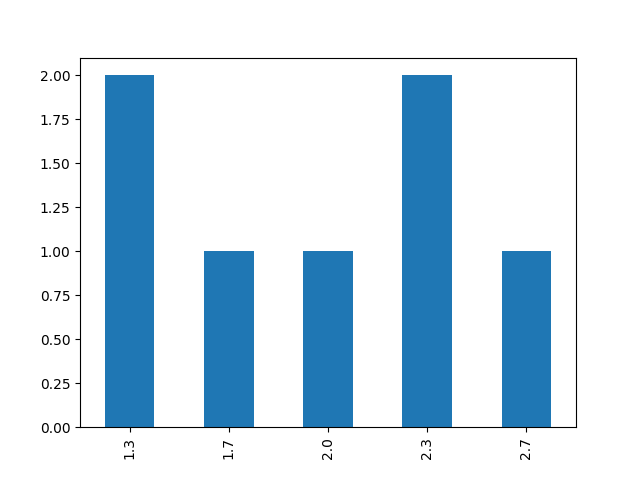

In [24]:
plt.subplots()
points["grade_with_bonus"].value_counts().sort_index().plot(kind="bar")

In [26]:
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/ADS/Grading/2024_ADS/ADS_Exam_2024_Retake_results_final.csv")
points.to_csv(exam_result_path, sep=";")